In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../data/traffic_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (254, 10)


,filename,date,timestamp,direction,day_night,weather,start_frame,number_of_frames,traffic_class,notes
0,cctv052x2004080516x01638,20040805,16.01638,south,day,overcast,2,53,medium,NaN
1,cctv052x2004080516x01639,20040805,16.01639,south,day,overcast,2,53,medium,NaN
2,cctv052x2004080516x01640,20040805,16.01640,south,day,overcast,2,48,light,NaN
3,cctv052x2004080516x01641,20040805,16.01641,south,day,overcast,2,52,medium,NaN
4,cctv052x2004080516x01642,20040805,16.01642,south,day,overcast,2,51,medium,NaN


In [3]:
#Select features and target
features = [
    "date",
    "timestamp",
    "direction",
    "day_night",
    "weather",
    "start_frame",
    "number_of_frames"
]

X = df[features].copy()
y = df["traffic_class"]

print("Features:", features)
print("Target: traffic_class")

Features: ['date', 'timestamp', 'direction', 'day_night', 'weather', 'start_frame', 'number_of_frames']
Target: traffic_class


In [4]:
#Encode categorical features
X = pd.get_dummies(
    X,
    columns=["direction", "day_night", "weather"],
    drop_first=False
)

print("Features encoded successfully!")
print("Total features:", X.shape[1])

Features encoded successfully!
Total features: 9


In [5]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 203
Testing samples: 51


In [7]:
#Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))

Logistic Regression Accuracy: 0.5882


In [9]:
#Decision Tree
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_pred = decision_tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:",
      round(tree_accuracy, 4))

Decision Tree Accuracy: 0.8039


In [11]:
#Random forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:",
      round(rf_accuracy, 4))

Random Forest Accuracy: 0.8824


In [12]:
#Compare models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

results["Accuracy"] = results["Accuracy"].round(4)

print(results)

                 Model  Accuracy
0  Logistic Regression    0.5882
1        Decision Tree    0.8039
2        Random Forest    0.8824


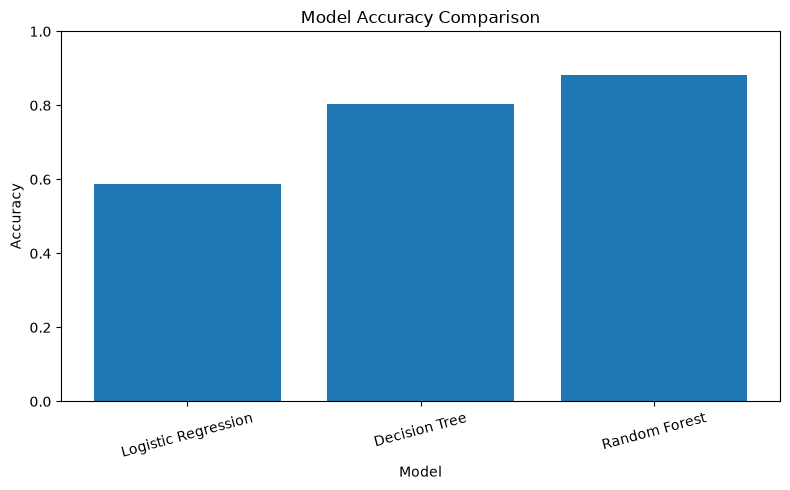

Graph saved to: d:\Traffice-System\outputs\model_accuracy_comparison.png


In [13]:
#Model accuracy graph
import matplotlib.pyplot as plt
import os

output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

path = os.path.join(
    output_dir,
    "model_accuracy_comparison.png"
)

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Graph saved to:", os.path.abspath(path))

In [15]:
#Best model
best_model_name = results.loc[
    results["Accuracy"].idxmax(), "Model"
]

best_accuracy = results["Accuracy"].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Random Forest
Best Accuracy: 0.8824


## Final observation
Three classification models were implemented: Logistic Regression, Decision Tree, and Random Forest.
The dataset was divided into training and testing sets.
Each model was trained using the selected features.
Model accuracy was calculated and compared.
Random Forest was selected as the model to be further improved through hyperparameter tuning.